In [19]:
import glob
import pickle
from collections import defaultdict
base = "/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting"

def merge_geom_pickles(pattern):
    merged = {}
    files = sorted(glob.glob(pattern))
    print(f"Found {len(files)} files for pattern: {pattern}")

    for fn in files:
        with open(fn, "rb") as f:
            d = pickle.load(f)

        for idx, entry in d.items():
            if not isinstance(entry, dict):
                continue
            if 'model_id' not in entry or 'chi2' not in entry:
                continue
            if len(entry['model_id']) == 0 or len(entry['chi2']) == 0:
                continue
            merged[idx] = entry

    return merged

combined_upper_dict = merge_geom_pickles(f"{base}/model_dict_upper_*.pkl")
combined_lower_dict = merge_geom_pickles(f"{base}/model_dict_lower_*.pkl")





Found 20 files for pattern: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_*.pkl
Found 20 files for pattern: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_lower_*.pkl


In [20]:
print(combined_upper_dict)

{np.int64(38): {'model_id': [np.int64(512918), np.int64(174935), np.int64(18830), np.int64(198), np.int64(314469), np.int64(5879), np.int64(235345), np.int64(184365), np.int64(325568), np.int64(42473)], 'geom': ['spubhmi', 'spubsmi', 'sp--s-i', 'sp--s-i', 'spubhmi', 'sp--smi', 'spubsmi', 'spubhmi', 'spubsmi', 'spu-smi'], 'chi2': [np.float64(10.964954503618541), np.float64(14.309430014933723), np.float64(14.348942979978991), np.float64(14.563420419977476), np.float64(16.235315451639543), np.float64(17.636994761309904), np.float64(18.073253442983322), np.float64(18.682641301003656), np.float64(18.814472072792267), np.float64(19.280574408448565)], 'av': [<Quantity 10.33814012>, <Quantity 19.31737708>, <Quantity 19.85916482>, <Quantity 29.01180185>, <Quantity 29.27946067>, <Quantity 18.25483247>, <Quantity 20.13432047>, <Quantity 24.74509117>, <Quantity 21.85416621>, <Quantity 27.57641339>], 'distance': [np.float64(5.3), np.float64(5.3), np.float64(5.3), np.float64(5.3), np.float64(5.50000

In [ ]:
all_upper_rows = [
    {'source_idx': src_idx, 'model_id': model_id, 'chi2': chi2}
    for src_idx, entry in combined_upper_dict.items()
    for model_id, chi2 in zip(entry['model_id'], entry['chi2'])
]

all_model_ids_upper = [
    model_id
    for entry in combined_upper_dict.values()
    for model_id in entry['model_id']
]

all_chi2_upper = [
    chi2
    for entry in combined_upper_dict.values()
    for chi2 in entry['chi2']
]



all_geo_upper = [
    geo
    for entry in combined_upper_dict.values()
    for geo in entry['geom']
]

all_lower_rows = [
    {'source_idx': src_idx, 'model_id': model_id, 'chi2': chi2}
    for src_idx, entry in combined_lower_dict.items()
    for model_id, chi2 in zip(entry['model_id'], entry['chi2'])
]
all_model_ids_lower = [
    model_id
    for entry in combined_lower_dict.values()
    for model_id in entry['model_id']
]
all_chi2_lower = [
    chi2
    for entry in combined_lower_dict.values()
    for chi2 in entry['chi2']
]

all_geo_lower = [
    geo
    for entry in combined_lower_dict.values()
    for geo in entry['geom']
]



In [24]:
import numpy as np
from astropy.table import Table

def map_to_class(class_indices):
    return -1*(class_indices-3)
import glob
from tqdm.auto import tqdm
all_gs = glob.glob('/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2/s*')
all_gs = [g.split('/')[-1] for g in all_gs if 'ipynb' not in g]

ap_ind = 3

class_dict = {}
classpoints = np.array([-1.6,-0.3,0.3,np.inf])
for g in tqdm(all_gs):
    geo = g.split('/')[-1]
    indices = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/spectral_indices/{geo}.fits')
    
    obs_class = np.searchsorted(classpoints,indices['Spectral Index'][:,ap_ind],side='right')
    obs_class = map_to_class(np.array(obs_class))
    #print('indices:',indices['Spectral Index'][:,ap_ind], 'obs_class:', obs_class)
    class_dict.update({geo:obs_class})
# assign class for the best model for each source
obs_classes_upper = []
obs_classes_lower = []

for geo, model_id in zip(all_geo_upper, all_model_ids_upper):
    obs_class = class_dict[geo][model_id]
    #print(f'geom: {geo}, model_id: {model_id}, class: {obs_class}')
    obs_classes_upper.append(obs_class)
for geo, model_id in zip(all_geo_lower, all_model_ids_lower):
    obs_class = class_dict[geo][model_id]
    #print(f'geom: {geo}, model_id: {model_id}, class: {obs_class}')
    obs_classes_lower.append(obs_class)




print('obs_classes_upper:', obs_classes_upper)


  0%|          | 0/18 [00:00<?, ?it/s]

obs_classes_upper: [np.int64(0), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.in

(array([2250, 2254, 2256, 2601, 4144, 4220, 4331, 4524, 4531, 4830, 4993,
       5286, 7807]),)
len(np.where(np.array(obs_classes_upper) == -1)): 13
len(np.where(np.array(obs_classes_lower) == -1)): 70


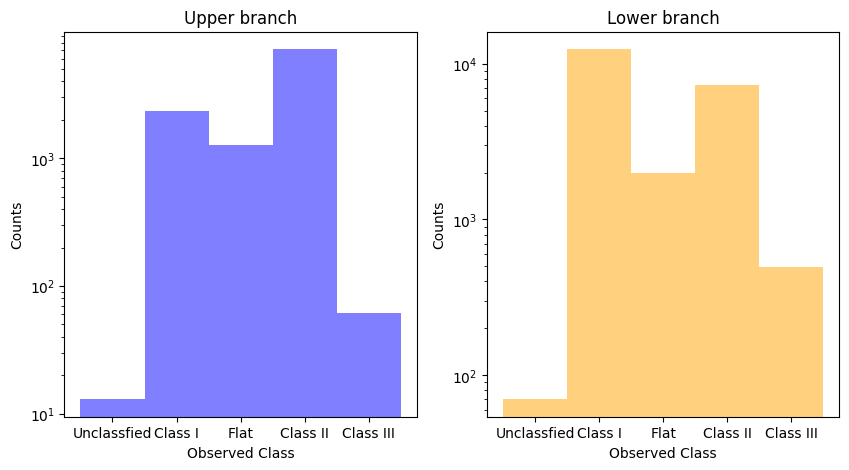

In [25]:
from matplotlib import pyplot as plt
print(np.where(np.array(obs_classes_upper) == -1))
print('len(np.where(np.array(obs_classes_upper) == -1)):', len(np.where(np.array(obs_classes_upper) == -1)[0]))
print('len(np.where(np.array(obs_classes_lower) == -1)):', len(np.where(np.array(obs_classes_lower) == -1)[0]))
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121)
ax1.hist(obs_classes_upper, bins=np.arange(-1,5)-0.5,  alpha=0.5, label='upper', color='blue')
#ax1.hist(obs_classes_lower, bins=np.arange(-1,4)-0.5, density=True, alpha=0.5, label='lower', color='orange')
ax1.set_xticks([-1,0,1,2,3])
ax1.set_yscale('log')
ax1.set_xticklabels(['Unclassfied', 'Class I','Flat','Class II','Class III'])
ax1.set_xlabel('Observed Class')
ax1.set_ylabel('Counts')
ax1.set_title('Upper branch')
ax2 = fig.add_subplot(122)
#ax2.hist(obs_classes_upper, bins=np.arange(-1,4)-0.5, density=True, alpha=0.5, label='upper', color='blue', cumulative=True, histtype='step')
ax2.hist(obs_classes_lower, bins=np.arange(-1,5)-0.5,  alpha=0.5, label='lower', color='orange',)
ax2.set_xticks([-1,0,1,2,3])
ax2.set_xticklabels(['Unclassfied', 'Class I','Flat','Class II','Class III'])
ax2.set_xlabel('Observed Class')
ax2.set_ylabel('Counts')
ax2.set_title('Lower branch')
ax2.set_yscale('log')


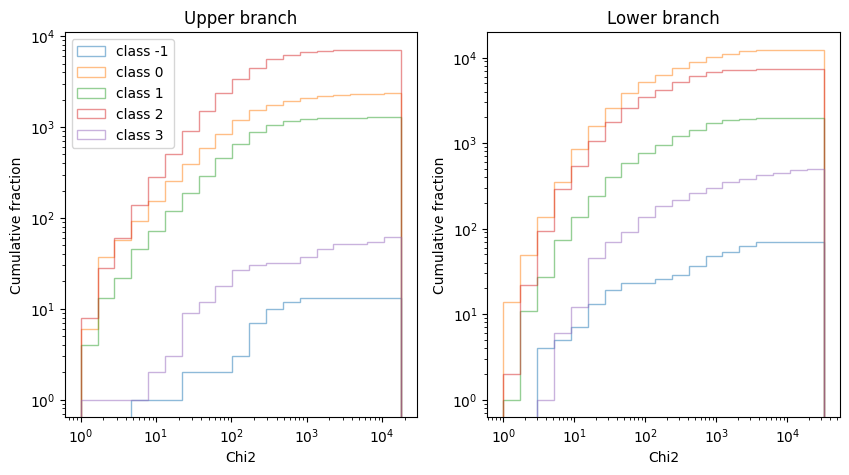

In [39]:
# make a cumulative histogram of the number of each class as a function of chi2
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121)
for obs_class in [-1,0,1,2,3]:
    chi2s = np.array(all_chi2_upper)[np.array(obs_classes_upper) == obs_class]
    ax1.hist(chi2s, bins=np.logspace(0, np.log10(np.nanmax(all_chi2_upper)), 20),  alpha=0.5, label=f'class {obs_class}', cumulative=True, histtype='step')
ax1.set_xlabel('Chi2')
ax1.set_ylabel('Cumulative fraction')
ax1.set_title('Upper branch')
ax1.set_yscale('log')
ax1.set_xscale('log')
ax2 = fig.add_subplot(122)
for obs_class in [-1,0,1,2,3]:  
    chi2s = np.array(all_chi2_lower)[np.array(obs_classes_lower) == obs_class]
    ax2.hist(chi2s, bins=np.logspace(0, np.log10(np.nanmax(all_chi2_lower)), 20),  alpha=0.5, label=f'class {obs_class}', cumulative=True, histtype='step')
ax2.set_xlabel('Chi2')
ax2.set_ylabel('Cumulative fraction')
ax2.set_title('Lower branch')
ax2.set_yscale('log')
ax2.set_xscale('log')
ax1.legend()

In [28]:
def geo_inc(geo):
    if (geo[2:4] == 'p-') or geo[:4] == 's---':
        return 1
    else:
        return 9
def phys_stage(pars,g):
    stage = -1*np.ones(len(pars))
    hasDisk = 'disk.mass' in pars.keys()
    hasEnv = 'envelope.rho_0' in pars.keys()
    hasMedium = 'ambient.temperature' in pars.keys()

    geo = g.split('/')[-1]
    incs = geo_inc(geo)
    stats = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/model_status/{geo}.fits')
    done_seds = np.ravel(stats['Exists'][:,None]*np.ones(incs)[None,:]).astype(int)
    exists = done_seds == 1
    if hasDisk or hasEnv:
        m_envs = np.nanmax(pars['Sphere Masses'][:,0],axis=-1)
        m_envs = np.ma.array(np.ravel(m_envs))
        if hasDisk:
            GDR = 100
            subs = m_envs - (GDR+1)*pars['disk.mass']
            #start stage 0; cool sources with massive envelopes                                                                                                                                                    
            stage0 = np.logical_and(subs > 0.1,pars['star.temperature'] < 3000)
            #cut down to models that actually have calculated sphere masses                                                                                                                                        
            stage0 = np.logical_and(stage0,~m_envs.mask)
            #cut further to models that exist                                                                                                                                                                      
            stage0 = np.logical_and(stage0,exists)
            stage[stage0] = 0
            #start stage I; prestellar sources with massive envelopes                                                                                                                                              
            stage1 = np.logical_and(subs > 0.1,pars['star.temperature'] > 3000)
            #cut to models with calculated sphere masses                                                                                                                                                           
            stage1 = np.logical_and(stage1,~m_envs.mask)
            #cut to existing models                                                                                                                                                                                
            stage1 = np.logical_and(stage1,exists)
            stage[stage1] = 1
            #start stage II; sources with disks                                                                                                                                                                    
            #including models w/o calculated sphere masses to catch disks within smallest aperture                                                                                                                 
            stage2 = np.logical_or(subs <= 0.1,m_envs.mask)
            #then cut models that don't exist                                                                                                                                                                      
            stage2 = np.logical_and(stage2,exists)
            stage[stage2] = 2
        else:
            #same deal as above, but no stage II                                                                                                                                                                   
            stage0 = np.logical_and(m_envs > 0.1,pars['star.temperature'] < 3000)
            stage0 = np.logical_and(stage0,~m_envs.mask)
            stage0 = np.logical_and(stage0,exists)
            stage[stage0] = 0
            stage1 = np.logical_and(m_envs > 0.1,pars['star.temperature'] > 3000)
            stage1 = np.logical_and(stage1,~m_envs.mask)
            stage1 = np.logical_and(stage1,exists)
            stage[stage1] = 1
        if hasMedium:
            #find models where there is no density above ambient medium (i.e. hidden s---smi)                                                                                                                      
            stage3 = np.logical_and(stats['Exists'] == 1,stats['Has Structure'] == 0)
        else:
            #find models with no density structures (i.e. hidden s---s-i)                                                                                                                                          
            stage3 = np.logical_and(stats['Exists'] == 1,stats['Density OK'] == 0)
        stage3 = np.ravel(stage3[:,None]*np.ones(incs)[None,:]).astype(int)
        stage[np.where(stage3)] = 3
    else:
        stage[exists] = 3
    return stage
stage_dict = {}
all_gs = glob.glob('/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2/s*')
all_gs = [g.split('/')[-1] for g in all_gs if 'ipynb' not in g]
for g in tqdm(all_gs):
    geo = g.split('/')[-1]
    pars_tab = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/pars/{geo}_augmented.fits')
    stage_from_geo = phys_stage(pars_tab, geo)

    stage_dict.update({geo:stage_from_geo})


physical_stages_upper = []
for geo, model_id in zip(all_geo_upper, all_model_ids_upper):
    stage =stage_dict[geo][model_id]

    physical_stages_upper.append(stage)
physical_stages_lower = []
for geo, model_id in zip(all_geo_lower, all_model_ids_lower):
    stage =stage_dict[geo][model_id]
    physical_stages_lower.append(stage)


  0%|          | 0/18 [00:00<?, ?it/s]

[np.float64(1.0), np.float64(1.0), np.float64(2.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(1.0), np.float64(1.0), np.float64(2.0), np.float64(2.0), np.float64(1.

Text(0.5, 1.0, 'Lower branch')

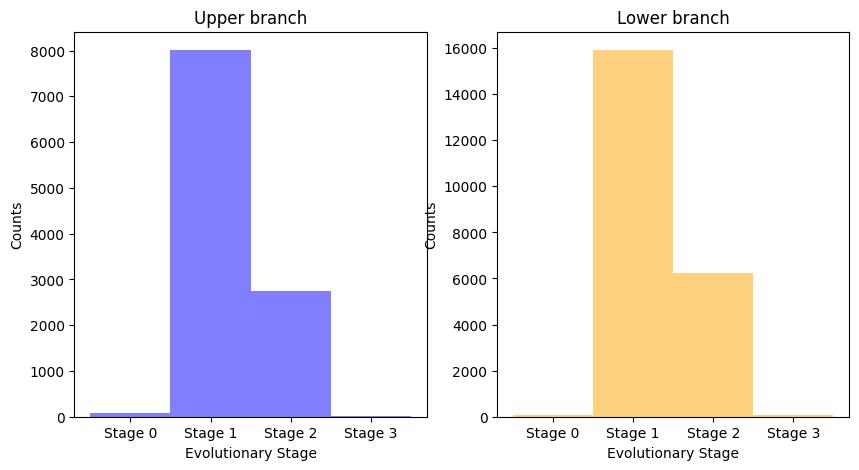

In [29]:
print(physical_stages_upper)
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121)
ax1.hist(physical_stages_upper, bins=np.arange(0,5)-0.5,  alpha=0.5, label='upper', color='blue')
#ax1.hist(obs_classes_lower, bins=np.arange(-1,4)-0.5, density=True, alpha=0.5, label='lower', color='orange')
ax1.set_xticks([0,1,2,3])
ax1.set_xticklabels(['Stage 0','Stage 1','Stage 2','Stage 3'])
ax1.set_xlabel('Evolutionary Stage')
ax1.set_ylabel('Counts')
ax1.set_title('Upper branch')
ax2 = fig.add_subplot(122)
#ax2.hist(obs_classes_upper, bins=np.arange(-1,4)-0.5, density=True, alpha=0.5, label='upper', color='blue', cumulative=True, histtype='step')
ax2.hist(physical_stages_lower, bins=np.arange(0,5)-0.5,  alpha=0.5, label='lower', color='orange',)
ax2.set_xticks([0,1,2,3])
ax2.set_xticklabels(['Stage 0','Stage 1','Stage 2','Stage 3'])
ax2.set_xlabel('Evolutionary Stage')
ax2.set_ylabel('Counts')
ax2.set_title('Lower branch')


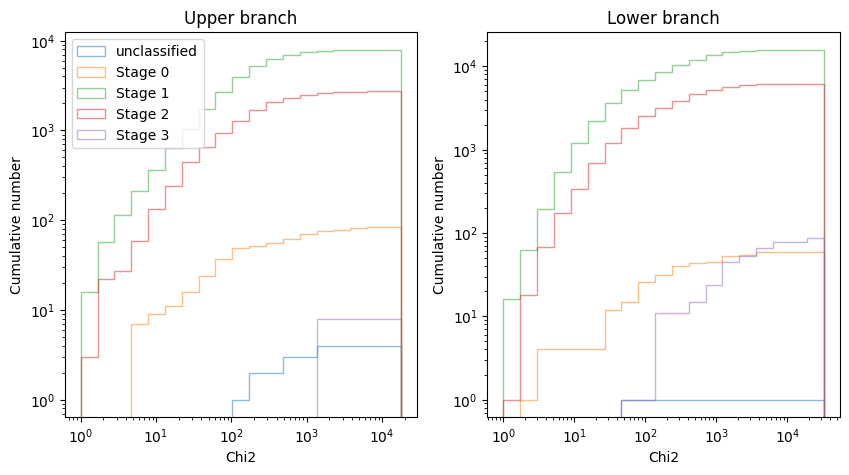

In [43]:
# make a cumulative histogram of the number of each stage as a function of chi2
stage_labels = ['unclassified', 'Stage 0', 'Stage 1', 'Stage 2', 'Stage 3']
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121)
for ii, stage in enumerate([-1,0,1,2,3]):
    chi2s = np.array(all_chi2_upper)[np.array(physical_stages_upper) == stage]
    ax1.hist(chi2s, bins=np.logspace(0, np.log10(np.nanmax(all_chi2_upper)), 20),  alpha=0.5, label=stage_labels[ii], cumulative=True, histtype='step')
ax1.set_xlabel('Chi2')
ax1.set_ylabel('Cumulative number')
ax1.set_title('Upper branch')
ax1.set_yscale('log')
ax1.set_xscale('log')
ax2 = fig.add_subplot(122)
for ii, stage in enumerate([-1,0,1,2,3]):  
    chi2s = np.array(all_chi2_lower)[np.array(physical_stages_lower) == stage]
    ax2.hist(chi2s, bins=np.logspace(0, np.log10(np.nanmax(all_chi2_lower)), 20),  alpha=0.5, label=stage_labels[ii], cumulative=True, histtype='step')
ax2.set_xlabel('Chi2')
ax2.set_ylabel('Cumulative number')
ax2.set_title('Lower branch')
ax2.set_yscale('log')
ax2.set_xscale('log')
ax1.legend()

In [ ]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121)
ax1.hist(physical_stages_best_upper, bins=np.arange(0,5)-0.5,  alpha=0.5, label='upper', color='blue')
#ax1.hist(obs_classes_lower, bins=np.arange(-1,4)-0.5, density=True, alpha=0.5, label='lower', color='orange')
ax1.set_xticks([0,1,2,3])
ax1.set_xticklabels(['Stage 0','Stage 1','Stage 2','Stage 3'])
ax1.set_xlabel('Evolutionary Stage')
ax1.set_ylabel('Counts')
ax1.set_title('Upper branch')
ax2 = fig.add_subplot(122)
#ax2.hist(obs_classes_upper, bins=np.arange(-1,4)-0.5, density=True, alpha=0.5, label='upper', color='blue', cumulative=True, histtype='step')
ax2.hist(physical_stages_best_lower, bins=np.arange(0,5)-0.5,  alpha=0.5, label='lower', color='orange',)
ax2.set_xticks([0,1,2,3])
ax2.set_xticklabels(['Stage 0','Stage 1','Stage 2','Stage 3'])
ax2.set_xlabel('Evolutionary Stage')
ax2.set_ylabel('Counts')
ax2.set_title('Lower branch')


In [ ]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from dust_extinction.parameter_averages import CCM89




def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err


image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}
catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]
print(catalog.colnames)


f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


num_sources = len(catalog)

from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = CT06_MWLoc()
def plot_extvec_cmd(ax, color1, mag1, ext=CT06_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None, label=None, fontsize=15):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y), fontsize=15,
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    if label is not None:
        ax.plot([], [], color=color, marker='>', markersize=8,
                label=f'{label}', linestyle='-', linewidth=2)

    else:
        ax.plot([], [], color=color, marker='>', markersize=8,
                linestyle='-', linewidth=2)

imgsavedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/cmds/'
mags = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(mags.keys())






In [ ]:
import matplotlib as mpl
from matplotlib.path import Path
from astropy.table import Table
import crds
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
print(np.min(m_init), np.max(m_init))
print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5
age_idx = logage_av0 == 6
idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
print(F162Mmag_av0)
print('age_idx:', age_idx, 'idx_01msun:', idx_01msun, 'idx_20msun:', idx_20msun)
isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isocrhone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isocrhone_y_end = F162Mmag_av0[age_idx][idx_20msun]
color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isocrhone_y_start - color_slope * isochrone_x_start

def get_av(color, mag, ext=CT06_MWLoc(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=None):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params
    print('color1:', color1, 'mag1:', mag1)

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av
parsec_mags = {
    'f140m': F140Mmag_av0,
    'f162m': F162Mmag_av0,
    'f182m': F182Mmag_av0,
    'f210m': F210Mmag_av0,
    'f335m': F335Mmag_av0,
    'f360m': F360Mmag_av0,
    'f410m': F410Mmag_av0,
    'f480m': F480Mmag_av0,
}

f162 = f162m_mag[0].to_value(u.mag)
f210 = f210m_mag[0].to_value(u.mag)
f360 = f360m_mag[0].to_value(u.mag)
f480 = f480m_mag[0].to_value(u.mag)
isochrone_x_start = parsec_mags['f162m'][age_idx][idx_01msun] - parsec_mags['f210m'][age_idx][idx_01msun]
isochrone_x_end = parsec_mags['f162m'][age_idx][idx_20msun] - parsec_mags['f210m'][age_idx][idx_20msun]
isochrone_y_start = parsec_mags['f162m'][age_idx][idx_01msun]
isochrone_y_end = parsec_mags['f162m'][age_idx][idx_20msun]

color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start
av_estimate = get_av(f162 - f210, f162, ext=CT06_MWLoc(), color1=('f162m', 'f210m'), mag1=('f162m',), isochrone_line_params=(color_slope, color_intercept))


upper_idx = f360-f480 > 0.15 + (1.5/6)*(f162-f210)
lower_idx = f360-f480 <= 0.15 + (1.5/6)*(f162-f210)



In [ ]:
print(len(idx_classes_best_upper), len(obs_classes_best_upper))

idx_classI_upper = np.array(idx_classes_best_upper)[np.where(np.array(obs_classes_best_upper) == 0)[0]]
idx_classFlat_upper = np.array(idx_classes_best_upper)[np.where(np.array(obs_classes_best_upper) == 1)[0]]
idx_classII_upper = np.array(idx_classes_best_upper)[np.where(np.array(obs_classes_best_upper) == 2)[0]]
idx_classIII_upper = np.array(idx_classes_best_upper)[np.where(np.array(obs_classes_best_upper) == 3)[0]]
idx_classI_lower = np.array(idx_classes_best_lower)[np.where(np.array(obs_classes_best_lower) == 0)[0]]
idx_classFlat_lower = np.array(idx_classes_best_lower)[np.where(np.array(obs_classes_best_lower) == 1)[0]]
idx_classII_lower = np.array(idx_classes_best_lower)[np.where(np.array(obs_classes_best_lower) == 2)[0]]
idx_classIII_lower = np.array(idx_classes_best_lower)[np.where(np.array(obs_classes_best_lower) == 3)[0]]

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f162[idx_classI_upper]-f210[idx_classI_upper], f360[idx_classI_upper]-f480[idx_classI_upper], edgecolor='red', facecolor='none', marker='o', label='Class I', alpha=0.5, s=3)
ax.scatter(f162[idx_classFlat_upper]-f210[idx_classFlat_upper], f360[idx_classFlat_upper]-f480[idx_classFlat_upper], edgecolor='red', facecolor='none', marker='s', label='Flat', alpha=0.5,s=3)
ax.scatter(f162[idx_classII_upper]-f210[idx_classII_upper], f360[idx_classII_upper]-f480[idx_classII_upper], edgecolor='red', facecolor='none', marker='^', label='Class II', alpha=0.5,s=3)
ax.scatter(f162[idx_classIII_upper]-f210[idx_classIII_upper], f360[idx_classIII_upper]-f480[idx_classIII_upper], edgecolor='red', facecolor='none', marker='v', label='Class III', alpha=0.5,s=3)
ax.scatter(f162[idx_classI_lower]-f210[idx_classI_lower], f360[idx_classI_lower]-f480[idx_classI_lower], edgecolor='blue', facecolor='none', marker='o', label='Class I', alpha=0.5, s=3)
ax.scatter(f162[idx_classFlat_lower]-f210[idx_classFlat_lower], f360[idx_classFlat_lower]-f480[idx_classFlat_lower], edgecolor='blue', facecolor='none', marker='s', label='Flat', alpha=0.5,s=3)
ax.scatter(f162[idx_classII_lower]-f210[idx_classII_lower], f360[idx_classII_lower]-f480[idx_classII_lower], edgecolor='blue', facecolor='none', marker='^', label='Class II', alpha=0.5,s=3)
ax.scatter(f162[idx_classIII_lower]-f210[idx_classIII_lower], f360[idx_classIII_lower]-f480[idx_classIII_lower], edgecolor='blue', facecolor='none', marker='v', label='Class III', alpha=0.5,s=3)
ax.set_xlabel('F162M - F210M (mag)')
ax.set_ylabel('F360M - F480M (mag)')
ax.set_title('Color-Color Diagram')

ax.legend()